# 🧠 Mental Health Text Classifier — 7-Class
**Model:** DeBERTa-v3-base  
**Dataset:** `suchintikasarkar/sentiment-analysis-for-mental-health` (Kaggle only)  
**Classes:** Normal · Depression · Anxiety · Suicidal · Stress · Bipolar · Personality Disorder

In [ ]:
#--------------------------------------------------------------------------------------------------------
# MODULE 0: Install / Update Libraries
#--------------------------------------------------------------------------------------------------------
!pip install -U transformers==4.48.0 huggingface_hub==0.27.0 accelerate sentencepiece --quiet
print("✅ Libraries ready.")

In [1]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1: Imports & Device Setup
#--------------------------------------------------------------------------------------------------------
import os
import gc
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoModel,
    AutoTokenizer,
    get_cosine_schedule_with_warmup
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}  |  PyTorch {torch.__version__}")

✅ Device: cuda  |  PyTorch 2.10.0+cu128


In [2]:
#--------------------------------------------------------------------------------------------------------
# MODULE 2: Configuration
#
# NOTE: No HuggingFace token needed — DeBERTa-v3-base is a public model.
#       Dataset is loaded entirely from the Kaggle input path.
#--------------------------------------------------------------------------------------------------------
class Config:
    # ── Model ────────────────────────────────────────────────────────────────
    MODEL_NAME = 'microsoft/deberta-v3-base'

    # ── Dataset path (Kaggle input) ──────────────────────────────────────────
    # After adding 'suchintikasarkar/sentiment-analysis-for-mental-health'
    # as a data source, the CSV lives here:
    DATA_PATH = '/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv'

    # ── 7 classes (exact labels in the dataset) ──────────────────────────────
    LABELS = [
        'Normal',
        'Depression',
        'Anxiety',
        'Suicidal',
        'Stress',
        'Bipolar',
        'Personality disorder',
    ]
    NUM_CLASSES = 7
    LABEL2ID = {lbl: i for i, lbl in enumerate(LABELS)}

    # ── Training hyper-parameters ─────────────────────────────────────────────
    MAX_LEN      = 256
    BATCH_SIZE   = 16
    EPOCHS       = 10
    LR           = 2e-5        # single learning rate (kept simple)
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    DROPOUT      = 0.3
    RANDOM_SEED  = 42

    # ── Focal loss gamma ──────────────────────────────────────────────────────
    FOCAL_GAMMA  = 2.0

    # ── Checkpoint name ───────────────────────────────────────────────────────
    CKPT = 'best_model_7class.bin'

config = Config()

# Convenience reverse map
ID2LABEL = {i: lbl for lbl, i in config.LABEL2ID.items()}

print("✅ Config ready.")
print(f"   Classes ({config.NUM_CLASSES}): {config.LABELS}")

✅ Config ready.
   Classes (7): ['Normal', 'Depression', 'Anxiety', 'Suicidal', 'Stress', 'Bipolar', 'Personality disorder']


In [3]:
#--------------------------------------------------------------------------------------------------------
# MODULE 3: Data Loading & Preprocessing
#
# Dataset: suchintikasarkar/sentiment-analysis-for-mental-health
#   - 51 074 unique posts, two columns: 'statement' and 'status'
#   - Labels: Normal, Depression, Anxiety, Suicidal,
#             Stress, Bipolar, Personality disorder
#--------------------------------------------------------------------------------------------------------

def clean_text(text: str) -> str:
    """Light normalisation — keeps clinical vocabulary intact."""
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # strip URLs
    text = re.sub(r'<[^>]+>', ' ', text)                # strip HTML tags
    text = re.sub(r'[^\w\s\'.,!?\-]', ' ', text)       # keep useful punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def load_dataset():
    df = pd.read_csv(config.DATA_PATH)
    print(f"Raw rows: {len(df):,}  |  Columns: {df.columns.tolist()}")

    # ── Flexible column detection ─────────────────────────────────────────
    text_col = next(
        (c for c in df.columns if 'statement' in c.lower() or 'text' in c.lower()),
        df.columns[0]
    )
    label_col = next(
        (c for c in df.columns if 'status' in c.lower() or 'label' in c.lower()),
        df.columns[1]
    )
    df = df[[text_col, label_col]].rename(
        columns={text_col: 'text', label_col: 'status'}
    )

    # ── Clean text ────────────────────────────────────────────────────────
    df['text'] = df['text'].apply(clean_text)
    df = df.drop_duplicates(subset=['text'])
    df = df.dropna(subset=['text', 'status'])

    # ── Normalise label strings ───────────────────────────────────────────
    df['status'] = df['status'].astype(str).str.strip()
    # Handle common capitalisation variants
    df['status'] = df['status'].replace({
        'personality disorder':  'Personality disorder',
        'Personality Disorder':  'Personality disorder',
        'personalitydisorder':   'Personality disorder',
        'normal':    'Normal',
        'depression': 'Depression',
        'anxiety':    'Anxiety',
        'suicidal':   'Suicidal',
        'stress':     'Stress',
        'bipolar':    'Bipolar',
    })

    # ── Keep only known classes ───────────────────────────────────────────
    df = df[df['status'].isin(config.LABELS)].reset_index(drop=True)

    # ── Encode labels ─────────────────────────────────────────────────────
    df['label'] = df['status'].map(config.LABEL2ID).astype(int)

    print(f"\nAfter cleaning: {len(df):,} rows")
    print("\nClass distribution:")
    dist = df['status'].value_counts()
    for cls, cnt in dist.items():
        bar = '█' * (cnt // 500)
        print(f"  {cls:<25} {cnt:>6}  {bar}")

    return df


df = load_dataset()

Raw rows: 53,043  |  Columns: ['Unnamed: 0', 'statement', 'status']

After cleaning: 51,055 rows

Class distribution:
  Normal                     16033  ████████████████████████████████
  Depression                 15086  ██████████████████████████████
  Suicidal                   10639  █████████████████████
  Anxiety                     3614  ███████
  Bipolar                     2501  █████
  Stress                      2288  ████
  Personality disorder         894  █


In [4]:
#--------------------------------------------------------------------------------------------------------
# MODULE 4: Train / Validation / Test Split
#
# Strategy:
#   - Hold out 300 samples per class as a stratified test set (never touched during training).
#   - Remaining data → 85% train / 15% val  (stratified).
#--------------------------------------------------------------------------------------------------------

# ── Stratified test set: 300 per class ───────────────────────────────────────
test_idx = (
    df.groupby('label', group_keys=False)
      .apply(lambda g: g.sample(min(300, len(g)), random_state=config.RANDOM_SEED))
      .index
)
final_test_df = df.loc[test_idx].copy().reset_index(drop=True)
train_val_df  = df.drop(test_idx).copy().reset_index(drop=True)

# ── Train / Val split ─────────────────────────────────────────────────────────
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    stratify=train_val_df['label'],
    random_state=config.RANDOM_SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# ── Data integrity check ──────────────────────────────────────────────────────
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
assert len(overlap) == 0, f"Leakage detected: {len(overlap)} overlapping samples!"

print(f"✅ Split complete — no train/test leakage.")
print(f"   Train  : {len(train_df):>6,} samples")
print(f"   Val    : {len(val_df):>6,} samples")
print(f"   Test   : {len(final_test_df):>6,} samples")

✅ Split complete — no train/test leakage.
   Train  : 41,611 samples
   Val    :  7,344 samples
   Test   :  2,100 samples


In [5]:
#--------------------------------------------------------------------------------------------------------
# MODULE 5: Tokenizer + Dataset + DataLoader
#--------------------------------------------------------------------------------------------------------

# ── Tokenizer ─────────────────────────────────────────────────────────────────
print("Loading tokenizer…")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print("✅ Tokenizer ready.")


# ── PyTorch Dataset ────────────────────────────────────────────────────────────
class MentalHealthDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts     = df['text'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ── Weighted sampler (handles class imbalance) ────────────────────────────────
def make_weighted_sampler(labels_array):
    """
    Inverse-frequency sampling so minority classes
    (Bipolar, Personality disorder, Suicidal) aren't under-represented.
    """
    counts  = np.bincount(labels_array, minlength=config.NUM_CLASSES).astype(float)
    weights = 1.0 / (counts + 1e-9)
    # Boost clinically critical minority classes
    weights[config.LABEL2ID['Suicidal']]            *= 1.8
    weights[config.LABEL2ID['Bipolar']]             *= 1.5
    weights[config.LABEL2ID['Personality disorder']] *= 1.5
    sample_w = weights[labels_array]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.float),
        num_samples=len(sample_w),
        replacement=True
    )


# ── Build DataLoaders ─────────────────────────────────────────────────────────
train_ds = MentalHealthDataset(train_df, tokenizer, config.MAX_LEN)
val_ds   = MentalHealthDataset(val_df,   tokenizer, config.MAX_LEN)
test_ds  = MentalHealthDataset(final_test_df, tokenizer, config.MAX_LEN)

sampler = make_weighted_sampler(train_df['label'].values)

train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ DataLoaders ready.")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches  : {len(val_loader)}")
print(f"   Test batches : {len(test_loader)}")

Loading tokenizer…


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✅ Tokenizer ready.
✅ DataLoaders ready.
   Train batches: 2601
   Val batches  : 459
   Test batches : 132


In [6]:
#--------------------------------------------------------------------------------------------------------
# MODULE 6: Model Architecture
#
# DeBERTa-v3-base  +  custom classification head:
#   [CLS] hidden → Dropout → Linear(768, 768) → GELU → Dropout → Linear(768, 7)
#
# Loss: Focal Loss (γ=2) with balanced class weights.
#   • Focal loss down-weights confident easy predictions (e.g. Normal)
#     so the model focuses on harder boundary cases.
#   • Class weights from sklearn 'balanced' correct for dataset imbalance.
#--------------------------------------------------------------------------------------------------------

class MentalHealthClassifier(nn.Module):
    def __init__(self, model_name, n_classes, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(
            model_name,
            ignore_mismatched_sizes=True
        )
        hidden = self.encoder.config.hidden_size  # 768 for deberta-v3-base

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden, n_classes)
        )

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls    = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return logits


# ── Focal Loss ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Focal loss (Lin et al., 2017)."""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight   # per-class weight tensor

    def forward(self, logits, targets):
        logits = logits.float()                # ✅ force FP32
        weight = self.weight.float() if self.weight is not None else None
        log_p  = F.log_softmax(logits, dim=1)
        ce     = F.nll_loss(log_p, targets, weight=weight, reduction='none')
        p_t    = torch.exp(-ce)
        loss   = ((1 - p_t) ** self.gamma) * ce
        return loss.mean()

# ── Class weights for Focal Loss ──────────────────────────────────────────────
cw = compute_class_weight(
    'balanced',
    classes=np.arange(config.NUM_CLASSES),
    y=train_df['label'].values
)
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
print("Class weights:")
for i, (lbl, w) in enumerate(zip(config.LABELS, class_weights.cpu())):
    print(f"  [{i}] {lbl:<25} → {w:.4f}")

print("\n✅ Model architecture defined.")

Class weights:
  [0] Normal                    → 0.4445
  [1] Depression                → 0.4730
  [2] Anxiety                   → 2.1102
  [3] Suicidal                  → 0.6764
  [4] Stress                    → 3.5195
  [5] Bipolar                   → 3.1771
  [6] Personality disorder      → 11.7711

✅ Model architecture defined.


Loading microsoft/deberta-v3-base…


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Epoch 9/10 [val]  :   0%|          | 0/459 [00:00<?, ?it/s]

  Epoch 09 | Loss: 0.0290 | Val Acc: 77.18% | Val Macro-F1: 76.24%
  💾 Checkpoint saved (best Val F1 = 76.24%)


Epoch 10/10 [train]:   0%|          | 0/2601 [00:00<?, ?it/s]

Epoch 10/10 [val]  :   0%|          | 0/459 [00:00<?, ?it/s]

  Epoch 10 | Loss: 0.0211 | Val Acc: 77.10% | Val Macro-F1: 76.02%


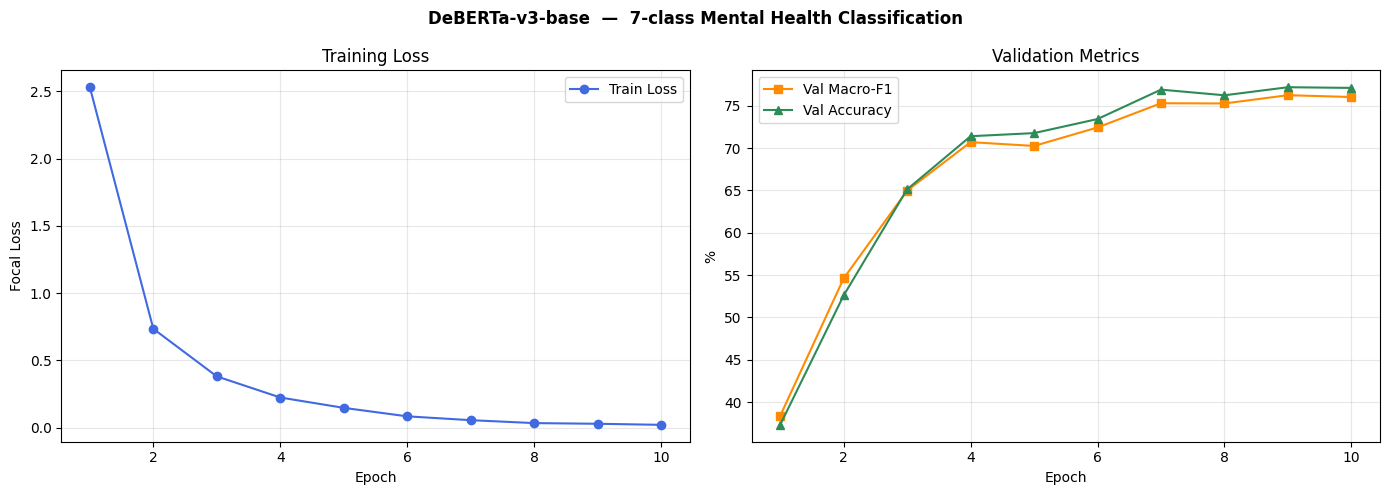

💾 Saved → training_curves.png

✅ Training complete. Best Val Macro-F1: 76.24%


In [7]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7: Training Loop
#--------------------------------------------------------------------------------------------------------

def run_training(model, train_loader, val_loader, ckpt_name):
    criterion = FocalLoss(gamma=config.FOCAL_GAMMA, weight=class_weights)

    optimizer = AdamW(
        model.parameters(),
        lr=config.LR,
        weight_decay=config.WEIGHT_DECAY
    )

    total_steps  = len(train_loader) * config.EPOCHS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler    = get_cosine_schedule_with_warmup(
        optimizer, warmup_steps, total_steps
    )

    best_f1   = 0.0
    train_losses, val_f1s, val_accs = [], [], []

    for epoch in range(1, config.EPOCHS + 1):
        # ────────────── TRAIN ──────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{config.EPOCHS} [train]")

        for batch in pbar:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['labels'].to(device)

            optimizer.zero_grad()

            logits = model(ids, mask)
            loss   = criterion(logits, lbls)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{running_loss / (pbar.n + 1):.4f}'})

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # ────────────── VALIDATE ───────────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{config.EPOCHS} [val]  ", leave=False):
                ids  = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                logits = model(ids, mask)
                preds  = logits.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch['labels'].numpy())

        val_f1  = f1_score(all_labels, all_preds, average='macro')
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1s.append(val_f1)
        val_accs.append(val_acc)

        print(
            f"  Epoch {epoch:02d} | Loss: {avg_loss:.4f} "
            f"| Val Acc: {val_acc*100:.2f}% "
            f"| Val Macro-F1: {val_f1*100:.2f}%"
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), ckpt_name)
            print(f"  \U0001f4be Checkpoint saved (best Val F1 = {best_f1*100:.2f}%)")

    # ── Training curves ────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs_x = range(1, config.EPOCHS + 1)
    ax1.plot(epochs_x, train_losses, 'o-', color='royalblue', label='Train Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Focal Loss')
    ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_x, [f * 100 for f in val_f1s],  's-', color='darkorange', label='Val Macro-F1')
    ax2.plot(epochs_x, [a * 100 for a in val_accs], '^-', color='seagreen',   label='Val Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('%')
    ax2.set_title('Validation Metrics'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('DeBERTa-v3-base  \u2014  7-class Mental Health Classification', fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print(f"\U0001f4be Saved \u2192 training_curves.png")
    print(f"\n\u2705 Training complete. Best Val Macro-F1: {best_f1*100:.2f}%")
    return best_f1


# ── Instantiate & train ────────────────────────────────────────────────────────
print(f"Loading {config.MODEL_NAME}\u2026")
model = MentalHealthClassifier(
    config.MODEL_NAME,
    n_classes=config.NUM_CLASSES,
    dropout=config.DROPOUT
).float().to(device)
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

best_f1 = run_training(model, train_loader, val_loader, config.CKPT)
del model
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Best model loaded.



Evaluating on test set:   0%|          | 0/132 [00:00<?, ?it/s]

════════════════════════════════════════════════════════════
           🧠  TEST SET EVALUATION — 7 CLASSES
════════════════════════════════════════════════════════════
  ✅ Overall Accuracy : 79.76%
  ✅ Macro F1 Score   : 79.25%

  📊 Per-Class Accuracy:
    Normal                     94.0%  ███████████████████████
    Depression                 51.0%  ████████████
    Anxiety                    93.0%  ███████████████████████
    Suicidal                   94.3%  ███████████████████████
    Stress                     83.0%  ████████████████████
    Bipolar                    84.3%  █████████████████████
    Personality disorder       58.7%  ██████████████

  📋 Full Classification Report:
                      precision    recall  f1-score   support

              Normal     0.8812    0.9400    0.9097       300
          Depression     0.6270    0.5100    0.5625       300
             Anxiety     0.7623    0.9300    0.8378       300
            Suicidal     0.6659    0.9433    0.7807     

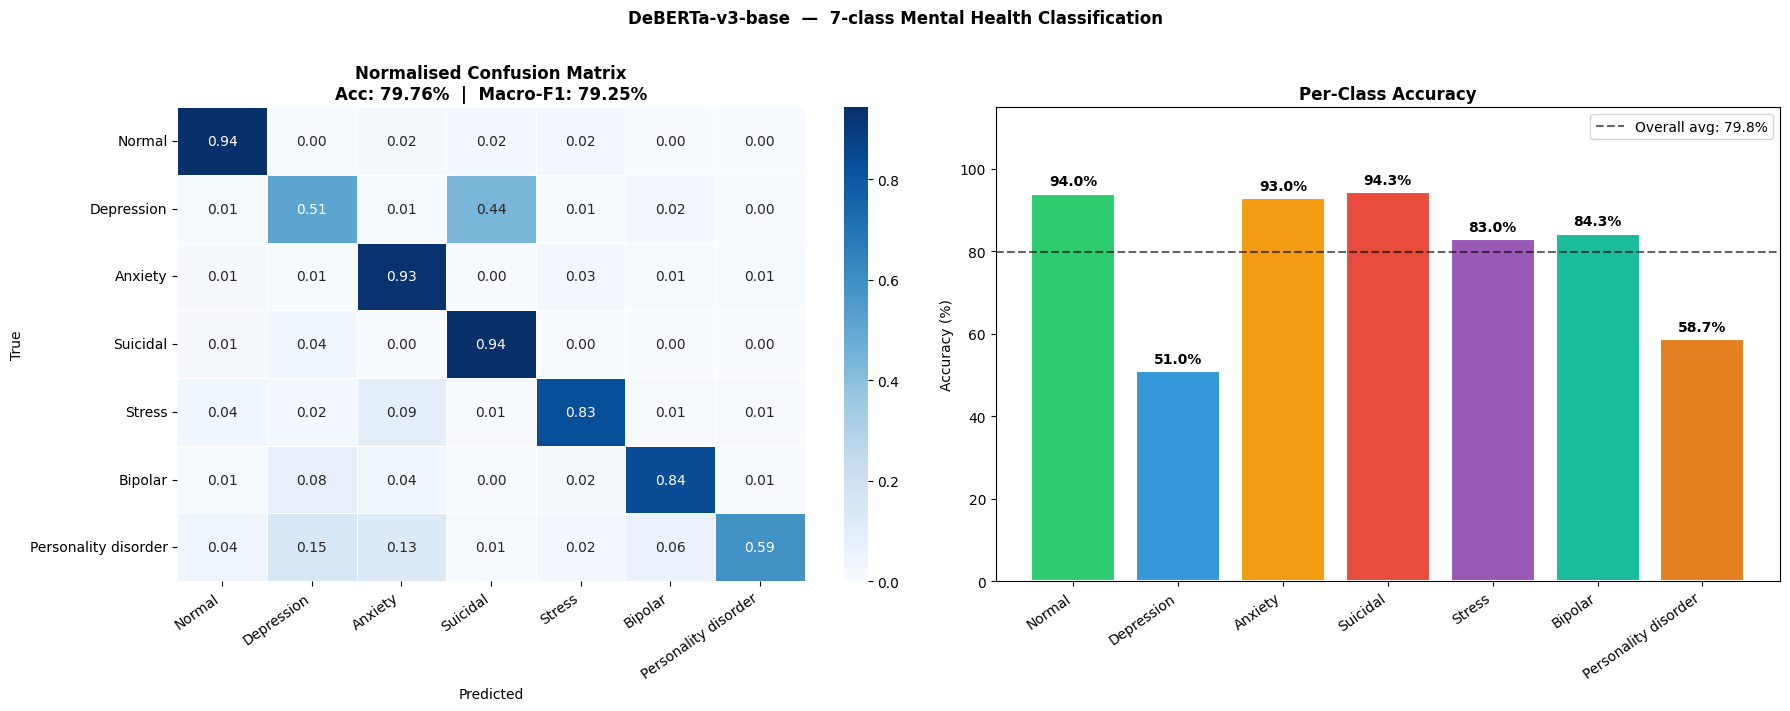

💾 Saved → test_evaluation.png


In [8]:
#--------------------------------------------------------------------------------------------------------
# MODULE 8: Evaluation on Held-Out Test Set
#--------------------------------------------------------------------------------------------------------

# ── Reload best checkpoint ────────────────────────────────────────────────────
eval_model = MentalHealthClassifier(
    config.MODEL_NAME,
    n_classes=config.NUM_CLASSES,
    dropout=config.DROPOUT
).float().to(device)
eval_model.load_state_dict(torch.load(config.CKPT, map_location=device))
eval_model.eval()
print("✅ Best model loaded.\n")

# ── Run inference ─────────────────────────────────────────────────────────────
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on test set"):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        logits = eval_model(ids, mask)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].numpy())
        all_probs.extend(probs.cpu().tolist())

# ── Metrics ───────────────────────────────────────────────────────────────────
overall_acc = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average='macro')
cm          = confusion_matrix(all_labels, all_preds)
per_class   = cm.diagonal() / cm.sum(axis=1)

print("═" * 60)
print("           🧠  TEST SET EVALUATION — 7 CLASSES")
print("═" * 60)
print(f"  ✅ Overall Accuracy : {overall_acc*100:.2f}%")
print(f"  ✅ Macro F1 Score   : {macro_f1*100:.2f}%")
print("\n  📊 Per-Class Accuracy:")
for lbl, acc in zip(config.LABELS, per_class):
    bar = '█' * int(acc * 25)
    print(f"    {lbl:<25} {acc*100:5.1f}%  {bar}")
print("\n  📋 Full Classification Report:")
print(classification_report(all_labels, all_preds, target_names=config.LABELS, digits=4))
print("═" * 60)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=config.LABELS, yticklabels=config.LABELS,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title(
    f'Normalised Confusion Matrix\nAcc: {overall_acc*100:.2f}%  |  Macro-F1: {macro_f1*100:.2f}%',
    fontweight='bold'
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right')

# Per-class accuracy bar chart
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6','#1abc9c','#e67e22']
bars = axes[1].bar(
    config.LABELS, per_class * 100,
    color=colors, edgecolor='white', linewidth=1.5
)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Class Accuracy', fontweight='bold')
axes[1].axhline(
    y=overall_acc * 100, color='black',
    linestyle='--', alpha=0.6,
    label=f'Overall avg: {overall_acc*100:.1f}%'
)
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=35, ha='right')
for bar, acc in zip(bars, per_class):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        acc * 100 + 2,
        f'{acc*100:.1f}%',
        ha='center', fontweight='bold', fontsize=10
    )

plt.suptitle('DeBERTa-v3-base  —  7-class Mental Health Classification', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → test_evaluation.png")

In [9]:
#--------------------------------------------------------------------------------------------------------
# MODULE 9: Inference Function
#--------------------------------------------------------------------------------------------------------

# Risk icons for display
RISK_ICONS = {
    'Normal':               '🟢 Normal',
    'Depression':           '🔵 Depression',
    'Anxiety':              '🟡 Anxiety',
    'Suicidal':             '🔴 Suicidal',
    'Stress':               '🟠 Stress',
    'Bipolar':              '🟣 Bipolar',
    'Personality disorder': '⚫ Personality disorder',
}


def predict(text: str):
    """
    Single-text inference.
    Returns:
        label      (str)  — predicted class name
        confidence (dict) — {class_name: probability} for all 7 classes
    """
    eval_model.eval()
    enc = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=config.MAX_LEN
    ).to(device)

    with torch.no_grad():
        logits = eval_model(enc['input_ids'], enc['attention_mask'])
        probs  = F.softmax(logits, dim=1).flatten().cpu()

    pred_idx = probs.argmax().item()
    label    = config.LABELS[pred_idx]
    confidence = {config.LABELS[i]: float(probs[i]) for i in range(config.NUM_CLASSES)}
    return label, confidence


# ── Sanity check ──────────────────────────────────────────────────────────────
test_cases = [
    ("I feel amazing today, everything is going really well!",                          'Normal'),
    ("I've been feeling so empty and hopeless for weeks, nothing helps.",               'Depression'),
    ("My anxiety is unbearable, I panic every time I leave the house.",                 'Anxiety'),
    ("I want to end my life, I don't see a way out.",                                   'Suicidal'),
    ("Work deadlines are crushing me, I can't stop worrying.",                          'Stress'),
    ("Last week I felt invincible, now I can't get out of bed — it swings wildly.",    'Bipolar'),
    ("My emotions and sense of identity are so unstable, relationships always collapse.",'Personality disorder'),
]

print("🧪 Sanity Check (7 classes)")
print('─' * 72)
for text, expected in test_cases:
    label, confs = predict(text)
    top3 = sorted(confs.items(), key=lambda x: -x[1])[:3]
    status = '✅' if label == expected else '⚠️'
    print(f"{status} Expected: {expected:<25} Got: {label}")
    print(f"   Text: {text[:65]}...")
    print(f"   Top-3: { {k: f'{v:.3f}' for k, v in top3} }")
    print()

🧪 Sanity Check (7 classes)
────────────────────────────────────────────────────────────────────────
✅ Expected: Normal                    Got: Normal
   Text: I feel amazing today, everything is going really well!...
   Top-3: {'Normal': '0.859', 'Depression': '0.093', 'Suicidal': '0.030'}

⚠️ Expected: Depression                Got: Suicidal
   Text: I've been feeling so empty and hopeless for weeks, nothing helps....
   Top-3: {'Suicidal': '0.554', 'Depression': '0.441', 'Normal': '0.003'}

✅ Expected: Anxiety                   Got: Anxiety
   Text: My anxiety is unbearable, I panic every time I leave the house....
   Top-3: {'Anxiety': '0.981', 'Normal': '0.010', 'Depression': '0.006'}

⚠️ Expected: Suicidal                  Got: Normal
   Text: I want to end my life, I don't see a way out....
   Top-3: {'Normal': '0.495', 'Suicidal': '0.272', 'Depression': '0.226'}

⚠️ Expected: Stress                    Got: Anxiety
   Text: Work deadlines are crushing me, I can't stop worrying...

In [10]:
#--------------------------------------------------------------------------------------------------------
# MODULE 10: Gradio Demo  (7 classes)
#--------------------------------------------------------------------------------------------------------
import gradio as gr


def predict_gradio(text):
    """Wrapper for Gradio — returns {icon_label: probability} dict."""
    try:
        label, confs = predict(text)
        return {RISK_ICONS[k]: v for k, v in confs.items()}
    except Exception as exc:
        return f"Runtime Error: {str(exc)}"


demo = gr.Interface(
    fn=predict_gradio,
    inputs=gr.Textbox(
        lines=5,
        label="Enter text to analyse",
        placeholder="Type or paste a social-media post, journal entry, or message…"
    ),
    outputs=gr.Label(
        num_top_classes=config.NUM_CLASSES,
        label="Mental Health Status — Confidence"
    ),
    title="🧠 Mental Health Text Classifier  (7 classes)",
    description=(
        "**DeBERTa-v3-base** fine-tuned on the "
        "*suchintikasarkar/sentiment-analysis-for-mental-health* Kaggle dataset.\n\n"
        "Classes: 🟢 Normal · 🔵 Depression · 🟡 Anxiety · 🔴 Suicidal · "
        "🟠 Stress · 🟣 Bipolar · ⚫ Personality disorder\n\n"
        "⚠️ *Research tool only — not a clinical diagnostic.*"
    ),
    examples=[
        ["I feel great today, everything is going well in my life."],
        ["I've been feeling really empty and hopeless lately, nothing brings me joy."],
        ["My anxiety is so bad I can't leave the house, I worry constantly."],
        ["I have been thinking about ending my life, I don't see a way out."],
        ["The pressure at work is overwhelming, I can't stop stressing."],
        ["I was full of energy and ideas all week, now I can't even get out of bed."],
        ["I don't know who I am anymore — my moods and relationships are completely unstable."],
    ],
    theme="soft"
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9739dd32a0f4287a80.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
#--------------------------------------------------------------------------------------------------------
# MODULE 11: Data Integrity & Final Summary
#--------------------------------------------------------------------------------------------------------
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"Train/Test leakage check: {len(overlap)} overlapping samples (must be 0) ✅")

print("\n" + "═" * 60)
print("  FINAL SUMMARY")
print("═" * 60)
print(f"  Dataset  : suchintikasarkar/sentiment-analysis-for-mental-health")
print(f"  Model    : {config.MODEL_NAME}")
print(f"  Classes  : {config.NUM_CLASSES}")
for i, lbl in enumerate(config.LABELS):
    print(f"             [{i}] {lbl}")
print(f"  Test Acc : {overall_acc*100:.2f}%")
print(f"  Macro-F1 : {macro_f1*100:.2f}%")
print("═" * 60)

Train/Test leakage check: 0 overlapping samples (must be 0) ✅

════════════════════════════════════════════════════════════
  FINAL SUMMARY
════════════════════════════════════════════════════════════
  Dataset  : suchintikasarkar/sentiment-analysis-for-mental-health
  Model    : microsoft/deberta-v3-base
  Classes  : 7
             [0] Normal
             [1] Depression
             [2] Anxiety
             [3] Suicidal
             [4] Stress
             [5] Bipolar
             [6] Personality disorder
  Test Acc : 79.76%
  Macro-F1 : 79.25%
════════════════════════════════════════════════════════════
